In [ ]:
using Pkg
Pkg.activate(normpath(@__DIR__, ".."))

In [ ]:
using CSV, DataFrames
include(normpath(joinpath(@__DIR__, "..", "utils", "utils.jl")))  #to calculate R^2

fb = CSV.read("eve_analysis/w7_K3_t0_fluo_hmm_results_final.csv", DataFrame); # inference results from cpHMM

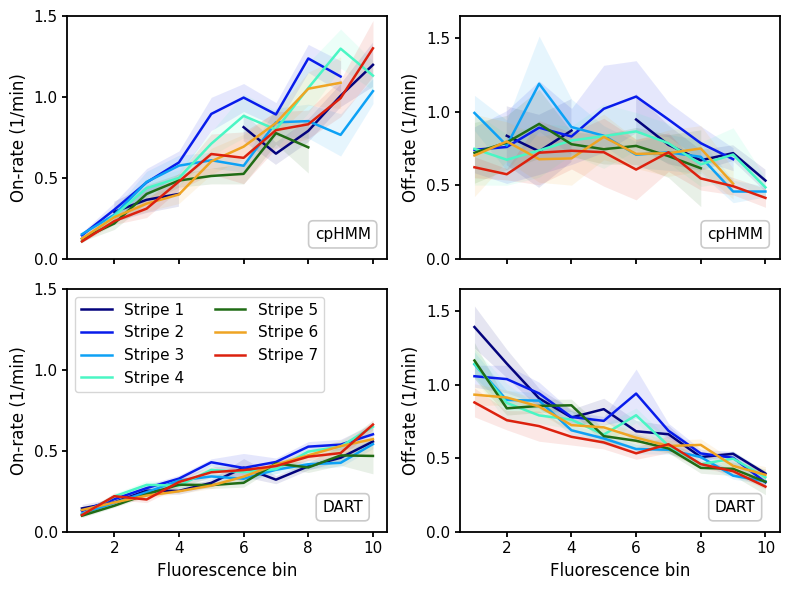

In [19]:
using DataFrames, Statistics, JLD2, StatsBase
using PyPlot

# ---- palette ----
cols = ["#04037d", "#081ceb", "#0da1f5", "#4af6c4","#206c15", "#efa423", "#dc210e"]

# ------------------------------
# First row data (fb dataframe)
# ------------------------------

df_xt = filter(row -> row.stripe_id == 0 && row.fluo_bin <= 9, fb)
if nrow(df_xt) == 0
    df_xt = filter(row -> row.fluo_bin <= 9, fb)   # fallback
end
sort!(df_xt, :mean_fluo)

# ------------------------------
# Load precomputed bootstrap summaries
# ------------------------------
@load "eve_analysis/boot_dl_results.jld2" mean_onrate sd_onrate mean_offrate sd_offrate Pon_mean;

# ------------------------------
# Figure: 2 rows × 3 cols
# ------------------------------
fig, axes = subplots(2, 2, figsize=(8, 6), sharex="col")
ax1_on, ax1_off = axes[1,:]
ax2_on,  ax2_off = axes[2,:]

fs1 = 12; fs2 = 11;

# ---- Row 1: kon, koff from cpHMM ----
for s in 1:7
    df = filter(row -> row.stripe_id == s, fb)
    nrow(df) == 0 && continue
    sort!(df, :mean_fluo)
    x = 1:10

    y_on, e_on = df.kon, df.kon_err
    ax1_on.plot(x, y_on, color=cols[s], lw=1.8, label="Stripe $s")
    ax1_on.fill_between(x, y_on .- e_on, y_on .+ e_on; color=cols[s], alpha=0.1, lw=0)

    y_off, e_off = df.koff, df.koff_err
    ax1_off.plot(x, y_off, color=cols[s], lw=1.8)
    ax1_off.fill_between(x, y_off .- e_off, y_off .+ e_off; color=cols[s], alpha=0.1, lw=0)
end

# ---- Row 2: on/off rates from DART ----
for s in 1:7
    x = 1:10

    y_on  = mean_onrate[s, :]
    sd_on = sd_onrate[s, :]
    ax2_on.plot(x, y_on, color=cols[s], lw=1.8, label="Stripe $s")
    ax2_on.fill_between(x, y_on .- sd_on, y_on .+ sd_on; color=cols[s], alpha=0.1, lw=0)

    y_off  = mean_offrate[s, :]
    sd_off = sd_offrate[s, :]
    ax2_off.plot(x, y_off, color=cols[s], lw=1.8)
    ax2_off.fill_between(x, y_off .- sd_off, y_off .+ sd_off; color=cols[s], alpha=0.1, lw=0)
end

# ---- Labels ----
ax1_on.set_ylabel("On-rate (1/min)", fontsize=fs1)
ax1_off.set_ylabel("Off-rate (1/min)", fontsize=fs1)

ax2_on.set_ylabel("On-rate (1/min)", fontsize=fs1)
ax2_off.set_ylabel("Off-rate (1/min)", fontsize=fs1)

ax2_on.set_xlabel("Fluorescence bin", fontsize=fs1)
ax2_off.set_xlabel("Fluorescence bin", fontsize=fs1)

# Styling
wd = 1.3
for ax in axes
    ax.tick_params(axis="both", labelsize=fs2, width=wd)
    for spine in values(ax.spines)
        spine.set_linewidth(wd)
    end
end

# Legend (Row 2 stripes)
ax2_on.legend(ncol=2, loc="upper left", fontsize=fs2)

# Column 1 (On rate)
ax1_on.set_ylim(0, 1.5); ax2_on.set_ylim(0, 1.5)
ax1_on.set_yticks(0:0.5:1.5); ax2_on.set_yticks(0:0.5:1.5)

# Column 2 (Off rate)
ax1_off.set_ylim(0, 1.65); ax2_off.set_ylim(0, 1.65)
ax1_off.set_yticks(0:0.5:1.5); ax2_off.set_yticks(0:0.5:1.5)


# Row 1 (cpHMM) labels
for ax in (ax1_on, ax1_off)
    ax.text(0.86, 0.07, "cpHMM", transform=ax.transAxes,
            fontsize=fs2, ha="center", va="bottom",
            bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
                      :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))
end

# Row 2 (DART) labels
for ax in (ax2_on, ax2_off)
    ax.text(0.86, 0.07, "DART", transform=ax.transAxes,
            fontsize=fs2, ha="center", va="bottom",
            bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
                      :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))
end

tight_layout()
savefig("figs/eve_compare.pdf", bbox_inches="tight")

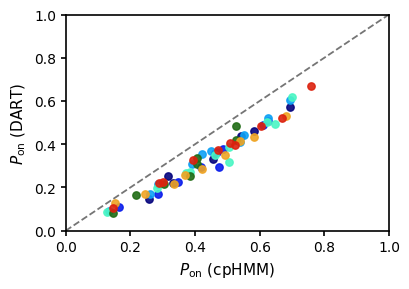

In [9]:
# ================================
# Scatter: Pon (fb) vs Pon (your case)
# ================================
fig_sc, ax = subplots(figsize=(4.2, 3))

all_x = Float64[]  # collect for correlation
all_y = Float64[]

fs1 = 11; fs2 = 10;

for s in 1:7
    # --- get fb (cpHMM) Pon for this stripe, ordered by bin ---
    df = filter(row -> row.stripe_id == s && row.fluo_bin <= 10, fb)
    nrow(df) == 0 && continue
    sort!(df, [:fluo_bin])  # safer alignment by bin

    # Pon from fb: kon / (kon + koff)
    denom_fb = df.kon .+ df.koff
    Pon_fb   = df.kon ./ denom_fb

    # --- get your-case Pon for the same bins ---
    # assume Pon_mean[s, :] is indexed by bin 1:10
    n_bins = min(length(Pon_fb), size(Pon_mean, 2))
    x = Pon_fb[1:n_bins]
    y = vec(Pon_mean[s, 1:n_bins])

    # drop NaNs just in case
    keep = .!(isnan.(x) .| isnan.(y))
    x = x[keep]; y = y[keep]

    # plot by stripe
    ax.scatter(x, y; s=28, color=cols[s], label="Stripe $s", alpha=0.9)

    # accumulate for correlation
    append!(all_x, x); append!(all_y, y)
end

# 1:1 reference line
xmin = 0.0; xmax = 1.0
ax.plot([xmin, xmax], [xmin, xmax]; lw=1.3, ls="--", color="#666666", alpha=0.9, zorder=0)

# labels and limits
ax.set_xlabel(L"$P_\mathrm{on}$ (cpHMM)",fontsize=fs1)
ax.set_ylabel(L"$P_\mathrm{on}$ (DART)",fontsize=fs1)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

#ax_sc.legend(ncol=2, fontsize=9, loc="lower right", frameon=false)

# Styling
wd = 1.2
ax.tick_params(axis="both", labelsize=fs2, width=wd)
for spine in values(ax.spines)
    spine.set_linewidth(wd)
end

fig_sc.tight_layout()
savefig("figs/pon_compare.pdf", bbox_inches="tight")

cpHMM fit: y = -0.11887 * x + 0.81701,  R² = 0.0702
DART  fit: y = -1.39853 * x + 1.21292,  R² = 0.7277


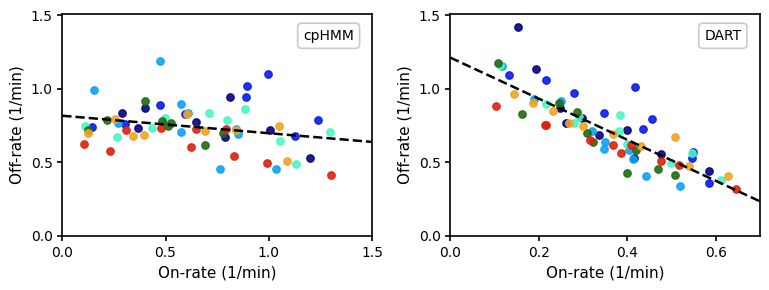

In [12]:
# ==================================
# Scatter: koff vs kon (cp vs da)
# ==================================
fig2, axs2 = subplots(1, 2, figsize=(7.8, 3))
ax_cp, ax_da = axs2

# containers for global fit
xs_cp = Float64[]; ys_cp = Float64[]
xs_da = Float64[]; ys_da = Float64[]

# ---------- Left: cp ----------
for s in 1:7
    df = filter(row -> row.stripe_id == s && row.fluo_bin <= 10, fb)
    nrow(df) == 0 && continue
    sort!(df, [:fluo_bin])

    kon_cp  = df.kon
    koff_cp = df.koff

    append!(xs_cp, kon_cp)
    append!(ys_cp, koff_cp)

    ax_cp.scatter(kon_cp, koff_cp; s=28, color=cols[s], label="Stripe $s", alpha=0.9)
end
ax_cp.set_xlabel("On-rate (1/min)", fontsize=fs1)
ax_cp.set_ylabel("Off-rate (1/min)", fontsize=fs1)

# ---------- Right: da ----------
for s in 1:7
    kon_da  = vec(mean_onrate[s, :])
    koff_da = vec(mean_offrate[s, :])

    keep = .!(isnan.(kon_da) .| isnan.(koff_da))
    kon_da  = kon_da[keep]
    koff_da = koff_da[keep]

    append!(xs_da, kon_da)
    append!(ys_da, koff_da)

    ax_da.scatter(kon_da, koff_da; s=28, color=cols[s], label="Stripe $s", alpha=0.9)
end
ax_da.set_xlabel("On-rate (1/min)", fontsize=fs1)
ax_da.set_ylabel("Off-rate (1/min)", fontsize=fs1)

# ---- shared styling ----
for ax in axs2
    ax.set_ylim(0, 1.51)
    ax.set_yticks(0.:0.5:1.5)
    ax.tick_params(axis="both", labelsize=fs2, width=1.2)
    for spine in values(ax.spines)
        spine.set_linewidth(1.2)
    end
end

ax_cp.set_xlim(0, 1.5)
ax_da.set_xlim(0, 0.7)
ax_cp.set_xticks(0.:0.5:1.5)
ax_da.set_xticks(0:0.2:0.6)

# ---------- Fit + R^2 ----------
m_cp, b_cp, r2_cp = fit_line(xs_cp, ys_cp)
xline_cp = range(ax_cp.get_xlim()[1], ax_cp.get_xlim()[2], length=200)
ax_cp.plot(xline_cp, m_cp .* xline_cp .+ b_cp, "k--", lw=1.8, label="Linear fit")
#ax_cp.text(0.05, 0.1, "R² = $(round(r2_cp, digits=3))",transform=ax_cp.transAxes, va="top", ha="left", fontsize=fs2)

m_da, b_da, r2_da = fit_line(xs_da, ys_da)
xline_da = range(ax_da.get_xlim()[1], ax_da.get_xlim()[2], length=200)
ax_da.plot(xline_da, m_da .* xline_da .+ b_da, "k--", lw=1.8, label="Linear fit")
#ax_da.text(0.05, 0.1, "R² = $(round(r2_da, digits=3))",transform=ax_da.transAxes, va="top", ha="left", fontsize=fs2)

# Labels
ax_cp.text(0.86, 0.87, "cpHMM", transform=ax_cp.transAxes, fontsize=fs2, ha="center", va="bottom",
    bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
    :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))

ax_da.text(0.88, 0.87, "DART", transform=ax_da.transAxes, fontsize=fs2, ha="center", va="bottom",
    bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
    :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))

fig2.tight_layout()
savefig("figs/kon_koff_compare.pdf", bbox_inches="tight")

println("cpHMM fit: y = $(round(m_cp,digits=5)) * x + $(round(b_cp,digits=5)),  R² = $(round(r2_cp,digits=4))")
println("DART  fit: y = $(round(m_da,digits=5)) * x + $(round(b_da,digits=5)),  R² = $(round(r2_da,digits=4))")

In [9]:
# read traces files (7 stripes 10 fuo groups)
all_traces10 = CSV.read("eve_analysis/all_concat_traces10.csv", DataFrame);

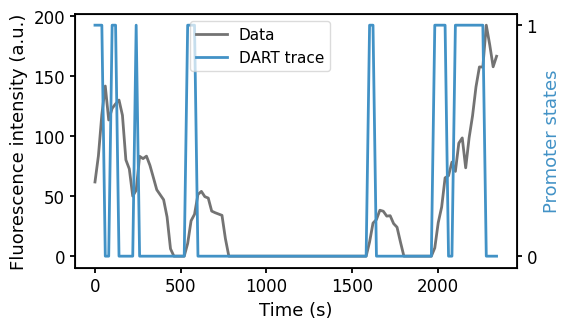

In [10]:
@load "eve_analysis/trained_trace10/dl_trace62.jld2" dl_trace62;

trace_subset = filter(row -> row.StripeID == 6 && row.fluobin_group == 2, all_traces10)

grouped = groupby(trace_subset, :particle_id)
traces_test = [collect(g.fluo) for g in grouped];

fig, (ax1) = plt.subplots(1,1,figsize=(5.7,3.3))

fs1 = 13
fs2 = 12
lw_val = 2
#t_int =1001:1500; 
id = 29 #29#24 #6 #1
y1 = traces_test[id]  #raw trace
x = 1:20:length(traces_test[id])*20

# binarized trace
start_idx = sum(length.(traces_test[1:id-1])) + 1
end_idx = start_idx + length(traces_test[id]) - 1
y2 = dl_trace62[id]#data_binar[start_idx:end_idx]

ax1.plot(x, y1,color="#737373",lw=lw_val,label="Data",zorder=1)#"#4575b4"
ax1.set_ylabel("Fluorescence intensity (a.u.)",fontsize=fs1); 
ax1.tick_params(axis="y");
ax1.set_xlabel("Time (s)",fontsize=fs1)
#ax1.set_title("An example trace")
    
ax11 = ax1.twinx()
ax11.plot(x, y2, color="#4292c6", label="DART trace",lw=lw_val,zorder=2) #"#fdae61"
ax11.set_ylabel("Promoter states",fontsize=fs1,color="#4292c6"); ax11.tick_params(axis="y") ##fdae61

ax11.set_ylim(-0.05, 1.05)
ax11.set_yticks([0.0, 1.0])
ax1.tick_params(axis="both", labelsize=fs2)
ax11.tick_params(axis="both", labelsize=fs2)

wd = 1.3
ax1.tick_params(axis="both", labelsize=fs2, width=wd)
ax11.tick_params(axis="both", labelsize=fs2, width=wd)
    
for spine in values(ax1.spines)
    spine.set_linewidth(wd)
end


# Get handles and labels from both ax1 and ax11
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax11.get_legend_handles_labels()
handles = vcat(h1, h2)
labels = vcat(l1, l2)
leg = fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.45, 0.88), fontsize=11,framealpha=0.7); # Put a combined legend on ax1 (or anywhere you prefer)
#bbox_to_anchor=(0.13, 0.69),
leg.set_zorder(3)
fig.savefig("figs/eve_binar62.pdf",bbox_inches="tight");

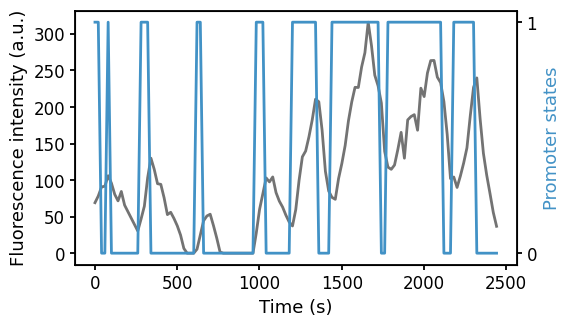

In [14]:
@load "eve_analysis/trained_trace10/dl_trace28.jld2" dl_trace28;

trace_subset = filter(row -> row.StripeID == 2 && row.fluobin_group == 8, all_traces10)

grouped = groupby(trace_subset, :particle_id)
traces_test = [collect(g.fluo) for g in grouped];

fig, (ax1) = plt.subplots(1,1,figsize=(5.7,3.3))

fs1 = 13
fs2 = 12
lw_val = 2
#t_int =1001:1500; 
id = 5#12 #5 
y1 = traces_test[id]  #raw trace
x = 1:20:length(traces_test[id])*20

# binarized trace
start_idx = sum(length.(traces_test[1:id-1])) + 1
end_idx = start_idx + length(traces_test[id]) - 1
y2 = dl_trace28[id]#data_binar[start_idx:end_idx]

ax1.plot(x, y1,color="#737373",lw=lw_val,label="Data",zorder=1)#"#4575b4"
ax1.set_ylabel("Fluorescence intensity (a.u.)",fontsize=fs1); 
ax1.tick_params(axis="y");
ax1.set_xlabel("Time (s)",fontsize=fs1)
#ax1.set_title("An example trace")
    
ax11 = ax1.twinx()
ax11.plot(x, y2, color="#4292c6", label="DART trace",lw=lw_val,zorder=2) #"#fdae61"
ax11.set_ylabel("Promoter states",fontsize=fs1,color="#4292c6"); ax11.tick_params(axis="y") ##fdae61

ax11.set_ylim(-0.05, 1.05)
ax11.set_yticks([0.0, 1.0])
ax1.tick_params(axis="both", labelsize=fs2)
ax11.tick_params(axis="both", labelsize=fs2)

wd = 1.3
ax1.tick_params(axis="both", labelsize=fs2, width=wd)
ax11.tick_params(axis="both", labelsize=fs2, width=wd)
    
for spine in values(ax1.spines)
    spine.set_linewidth(wd)
end


# Get handles and labels from both ax1 and ax11
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax11.get_legend_handles_labels()
handles = vcat(h1, h2)
labels = vcat(l1, l2)
#leg = fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(0.13, 0.69),fontsize=11,framealpha=0.7); # Put a combined legend on ax1 (or anywhere you prefer)
#leg.set_zorder(3)
fig.savefig("figs/eve_binar28.pdf",bbox_inches="tight");